# WaterGym quickstart

Make a sea, fly an International Moth through it with the mechanical wand, plot the ride height, and draw a few frames. It runs on a free CPU runtime in about a minute.

[Open in Colab](https://colab.research.google.com/github/mariusud/watergym/blob/main/notebooks/quickstart.ipynb).

## Install

Locally, run `uv sync` and skip this cell.

In [ ]:
# TODO: placeholder URL, the repository is not public yet.
%pip install -q "watergym @ git+https://github.com/mariusud/watergym.git" matplotlib

## Make a sea

`SeaState` describes the spectrum. `WaterEnv` draws one random sea per env, so 4 envs means 4 different seas. `heading_rad=pi` sends the waves at the bow.

In [1]:
import math

import matplotlib.pyplot as plt
import torch

from watergym import SeaState, WaterEnv
from watergym.vessels import moth
from watergym.vessels.moth_vessel import HULL_BOTTOM_Z, wand_action

sea_state = SeaState(hs=0.3, tp=3.0, heading_rad=math.pi, spreading=10.0, num_components=48)
env = WaterEnv(moth(), num_envs=4, sea_state=sea_state, device="cpu")
obs, info = env.reset(seed=0)
obs.shape

torch.Size([4, 12])

## Step the Moth with the wand

The action is `[sail, flap]`. `wand_action` reads the water height under the wand pivot and sets the flap, as the wand on a real Moth does. Each step is 0.02 s, so 400 steps is 8 s.

In [2]:
times, ride, track = [], [], []
for _ in range(400):
    action = wand_action(env.sea, env.t, env.eta)
    env.step(action)
    times.append(env.t[0].item())
    ride.append((-env.eta[0, 2] - HULL_BOTTOM_Z).item())  # hull bottom above mean water
    track.append(env.eta[0, :6].clone())
print(f"final speed {env.nu[0, 0]:.1f} m/s, ride height {ride[-1]:.2f} m")

final speed 8.4 m/s, ride height 0.50 m


## Ride height over time

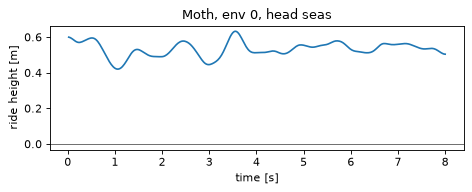

In [3]:
fig, ax = plt.subplots(figsize=(6, 2.5), dpi=80)
ax.plot(times, ride)
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="time [s]", ylabel="ride height [m]", title="Moth, env 0, head seas")
fig.tight_layout()
plt.show()

## Draw a few frames

This notebook draws with matplotlib 3D, which needs nothing beyond the install above. For Newton's viewer, install the `viz` extra and run `examples/03_moth_on_foils.py --headless --screenshot out.png`. That path needs OpenGL, which a Colab runtime may not provide.

Each frame shows the sea around env 0 at one moment, and the hull as a line.

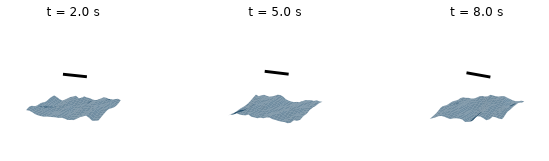

In [4]:
from watergym.waves import elevation


def draw_frame(ax, k):
    t_k, (x, y, z, _, pitch, _) = times[k], track[k]
    gx, gy = torch.meshgrid(
        torch.linspace(x - 6, x + 6, 25), torch.linspace(y - 4, y + 4, 17), indexing="ij"
    )
    pts = (
        torch.stack((gx, gy, torch.zeros_like(gx)), -1)
        .reshape(1, -1, 3)
        .expand(env.num_envs, -1, -1)
    )
    t = torch.full((env.num_envs,), t_k)
    zs = elevation(env.sea, pts, t)[0].reshape(gx.shape)
    ax.plot_surface(gx, gy, zs, color="tab:blue", alpha=0.6, linewidth=0)
    dx, dz = 1.8 * math.cos(pitch), 1.8 * math.sin(pitch)  # NED z is down, so +pitch lifts the bow
    ax.plot([x - dx, x + dx], [y, y], [-z - dz, -z + dz], color="k", lw=3)
    ax.set(zlim=(-0.2, 1.2), title=f"t = {t_k:.1f} s")
    ax.set_axis_off()
    ax.view_init(elev=15, azim=-70)


fig = plt.figure(figsize=(9, 2.4), dpi=70)
for i, k in enumerate((100, 250, 399)):
    draw_frame(fig.add_subplot(1, 3, i + 1, projection="3d"), k)
fig.tight_layout()
plt.show()

## Next

- [Tutorials](../docs/tutorials/README.md): your own vessel, batching, MPS and CUDA.
- [Concepts](../docs/concepts/README.md): frames, waves, buoyancy, foils.
- [Examples](../examples): four runnable scripts with a viewer.